# Benchmarking compression efficiency across different models

> ### Reproducibility &amp; data
>
> This notebook reproduces the cross-architecture benchmark comparison from the in-repo `saved_data/` caches (incl. `../../simulations/VAE_gLV_simulation/saved_data/`).
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

## bgLV (fixed)

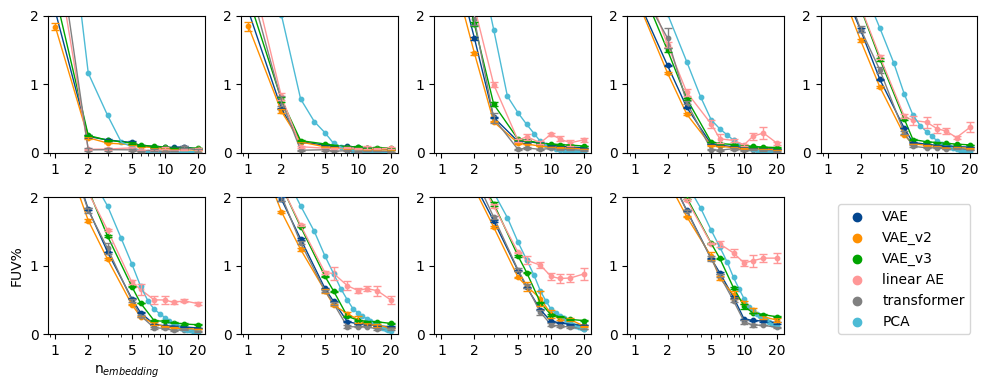

In [3]:
colors = ['#03468F', '#FF9000', '#00A400', '#FF9797', '#808080', '#4DBBD5']

labels = ["VAE", "VAE_v2", "VAE_v3", "linear AE", "transformer", "PCA"]
NT=np.arange(2,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="fixed"
model_index=1
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data1=np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data2=np.loadtxt(f"./saved_data/VAE_v2/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data3=np.loadtxt(f"./saved_data/VAE_v3/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data4=np.loadtxt(f"./saved_data/AE/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data5=np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data6=np.loadtxt(f"./saved_data/PCA/{glv_type}gLV/I{model_index}/PCA_T{n_target}_{sim_type}_FUV.txt")
    for j,data in enumerate([data1, data2, data3, data4, data5, data6]):
        N_EBD=data[0,:]
        FUV = data[1:,:]
        if FUV.shape[0]>1:
            mean = np.mean(FUV, axis=0)
            se = np.std(FUV, axis=0, ddof=1)/np.sqrt(FUV.shape[0])
        else:
            mean = FUV[0,:]
            se = np.zeros_like(mean)*np.nan
        ax.scatter(N_EBD,mean,s=10,c=colors[j],label=labels[j])
        ax.plot(N_EBD,mean,linewidth=1,c=colors[j])
        ax.errorbar(N_EBD,mean,yerr=se,fmt='none',c=colors[j],elinewidth=1,capsize=3,zorder=10)
    ax.set_ylim([0,2])
    ax.set_yticks([0,1,2])
    ax.set_xscale("log")
    ax.set_xticks([1,2,5,10,20])
    ax.set_xticklabels([1,2,5,10,20])
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
ax=axes[-1]
for i, label in enumerate(labels):
    ax.scatter([], [], c=colors[i], label=label)
ax.legend()
ax.axis('off')
fig.tight_layout()

## bgLV (random)

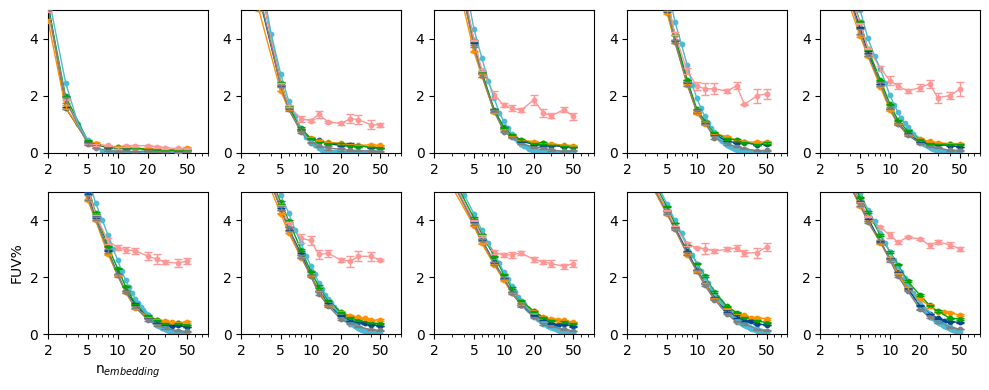

In [4]:
NT=np.arange(1,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="random"
model_index=1
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data1=np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data2=np.loadtxt(f"./saved_data/VAE_v2/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data3=np.loadtxt(f"./saved_data/VAE_v3/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data4=np.loadtxt(f"./saved_data/AE/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data5=np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data6=np.loadtxt(f"./saved_data/PCA/{glv_type}gLV/I{model_index}/PCA_T{n_target}_{sim_type}_FUV.txt")
    for j,data in enumerate([data1, data2, data3, data4, data5, data6]):
        N_EBD=data[0,:]
        FUV = data[1:,:]
        if FUV.shape[0]>1:
            mean = np.mean(FUV, axis=0)
            se = np.std(FUV, axis=0, ddof=1)/np.sqrt(FUV.shape[0])
        else:
            mean = FUV[0,:]
            se = np.zeros_like(mean)*np.nan
        ax.scatter(N_EBD,mean,s=10,c=colors[j],label=labels[j])
        ax.plot(N_EBD,mean,linewidth=1,c=colors[j])
        ax.errorbar(N_EBD,mean,yerr=se,fmt='none',c=colors[j],elinewidth=1,capsize=3,zorder=10)
    ax.set_ylim([0,5])
    ax.set_yticks([0,2,4])
    ax.set_xscale("log")
    ax.set_xlim([2,80])
    ax.set_xticks([2,5,10,20,50])
    ax.set_xticklabels([2,5,10,20,50])
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
fig.tight_layout()

## dgLV (fixed)

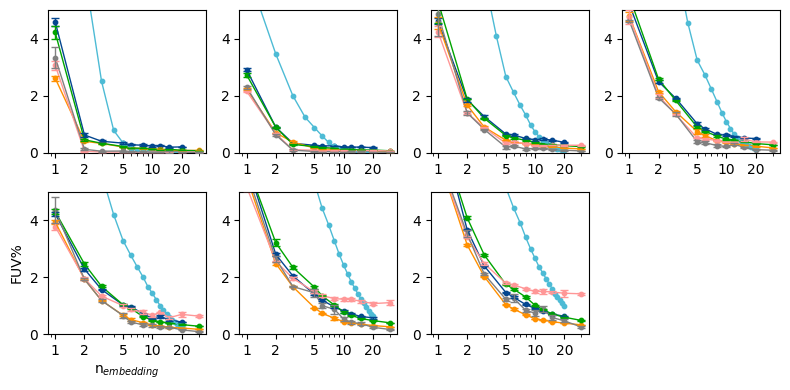

In [5]:
NT=np.arange(2,9,1)
n_ori=100
n_trial = 5
glv_type="d"
sim_type="fixed"
model_index=1
fig,axes=plt.subplots(2,4,figsize=(8,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data1=np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data2=np.loadtxt(f"./saved_data/VAE_v2/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data3=np.loadtxt(f"./saved_data/VAE_v3/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data4=np.loadtxt(f"./saved_data/AE/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data5=np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data6=np.loadtxt(f"./saved_data/PCA/{glv_type}gLV/I{model_index}/PCA_T{n_target}_{sim_type}_FUV.txt")
    for j,data in enumerate([data1, data2, data3, data4, data5, data6]):
        N_EBD=data[0,:]
        FUV = data[1:,:]
        if FUV.shape[0]>1:
            mean = np.mean(FUV, axis=0)
            se = np.std(FUV, axis=0, ddof=1)/np.sqrt(FUV.shape[0])
        else:
            mean = FUV[0,:]
            se = np.zeros_like(mean)*np.nan
        ax.scatter(N_EBD,mean,s=10,c=colors[j],label=labels[j])
        ax.plot(N_EBD,mean,linewidth=1,c=colors[j])
        ax.errorbar(N_EBD,mean,yerr=se,fmt='none',c=colors[j],elinewidth=1,capsize=3,zorder=10)
    ax.set_ylim([0,5])
    ax.set_yticks([0,2,4])
    ax.set_xscale("log")
    ax.set_xticks([1,2,5,10,20])
    ax.set_xticklabels([1,2,5,10,20])
    if i==4:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
axes[-1].set_visible(False)
fig.tight_layout()